### 1.投票分类器

#### 1.1 先以硬投票为例

In [2]:
# 导入库
from sklearn.datasets import make_moons # 生成“月亮型”二分类数据
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier # 集成学习子模块
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 数据生成与预处理
X,y = make_moons(n_samples=500,noise=0.30,random_state=42)
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42) # 默认情况下为3：1比例

# 构建投票分类器
# 先实例化一个投票分类器对象
voting_clf = VotingClassifier(
    # 一个元素为元组的列表，每个元组的形式是 ('名称', 模型实例)
    estimators=[
        ('lr',LogisticRegression(random_state=42)),
        ('rf',RandomForestClassifier(random_state=42)),
        ('svc',SVC(random_state=42))
    ]
)
'''这里使用了硬投票（Hard Voting）。
当模型进行预测时，这三个子模型会各自投出一票，
最终结果取票数最多的那个类别（少数服从多数）'''
voting_clf.fit(X_train,y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True


In [3]:
# 结果评估
# name 会取到 'lr', 'rf', 'svc'，而 clf 则是"对应的模型对象"
for name, clf in voting_clf.named_estimators_.items():
    print(name, "=", clf.score(X_test, y_test)) # 调用评分函数计算模型在测试集上的准确率
print(voting_clf.predict(X_test[:1]))
print([clf.predict(X_test[:1]) for clf in voting_clf.estimators_])
voting_clf.score(X_test,y_test)

lr = 0.864
rf = 0.896
svc = 0.896
[1]
[array([1]), array([1]), array([0])]


0.912

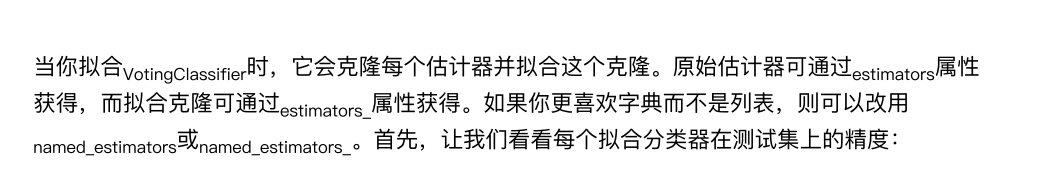
下面解释图片中提到的“克隆”与“独立拟合”逻辑：

### 1. 为什么要“克隆”（Clone）？
在 Python 中，对象通常是通过“引用”传递的。如果你直接使用你定义的 `lr`（逻辑回归），一旦它在一个地方被训练了，它的内部参数就会改变。

*   **防止污染**：`VotingClassifier` 不想直接修改你传入的原始模型实例。 **(比如对比实验中我们防止模型带有上一次训练的记忆)** 它通过 `sklearn.base.clone` 功能，给每个模型制作了一个“出厂设置状态”的精确复制品。
*   **实验复现**：这样即使 `VotingClassifier` 训练完了，你手头原始的 `LogisticRegression` 对象依然是干净、未训练的，方便你后续单独拿它去做别的实验。

### 2. 什么是“独立地拟合”（Fit Independently）？
虽然这三个模型（LR, RF, SVC）都在使用同一套 `X_train` 和 `y_train`，但它们的**学习机制**是互不干扰的：

*   **并行学习**：逻辑回归在寻找最佳拟合线，随机森林在构建决策树，而 SVM 在寻找最大间隔超平面。
*   **各司其职**：它们就像三个学生坐在同一个教室（同一套数据）里听课。虽然教材一样，但逻辑回归学生擅长线性推导，随机森林学生擅长逻辑拆解，SVM 学生擅长空间想象。
*   **参数独立**：训练完成后，逻辑回归学到的权重系数 $\beta$ 不会影响到随机森林的树结构。

### 3. 这意味着什么？（核心逻辑）
这种设计的最终目的是实现 **“群体智慧”**。

| 步骤 | 实际发生的逻辑 |
| :--- | :--- |
| **数据分发** | `VotingClassifier` 将 `X_train` 复制三份，分别递给克隆出的三个子模型。 |
| **独立进化** | 三个模型在各自的内存空间里，根据同一份数据调整自己的内部参数。 |
| **最终集成** | 当你调用 `predict()` 时，`VotingClassifier` 会问这三个已经学成归来的模型：“你们怎么看这个新数据？” |

**总结深层含义：**
这意味着集成模型并不是把三个算法“揉成一个公式”，而是 **“分头行动，汇总结果”**。即使其中一个模型（比如逻辑回归）在某些非线性数据上表现很差，另外两个模型（随机森林和 SVM）也可以通过多数票来纠正这个错误。

这种“克隆并独立拟合”的机制，正是集成学习能够比单一模型更鲁棒、更强大的底层保障。

#### 1.2 下面展示软投票

### 概念辨析：什么是软投票（Soft Voting）？

相对于“少数服从多数”的硬投票，软投票是一种**基于概率平均**的决策方式。

*   **核心原理**：如果所有的分类器都能预测类别的概率（即在 Scikit-Learn 中拥有 `predict_proba()` 方法），你可以计算所有分类器对每个类别预测概率的**平均值**。最终，预测结果将指向具有最高平均概率的类。
*   **为什么更好**：软投票通常比硬投票表现更出色。因为它不仅考虑了“投给谁”，还考虑了“确信度”。它会给那些高度自信（概率值很高）的投票更多的权重。

In [ ]:
# 前提条件：所有参与投票的分类器都必须能够估算概率
voting_clf.voting = "soft" # 将模式改为软投票
voting_clf.named_estimators['svc'].probability = True 
'''默认情况下，SVC（支持向量机）不提供概率估算
我们需要手动进行修改，这会使 SVC 使用交叉验证来估算概率，从而减慢训练速度
不加下划线，是因为代码正在修改配置（把 SVC 设为可估算概率的状态），以便随后进行的 fit() 操作能正确克隆这个新设置'''
voting_clf.fit(X_train,y_train)
voting_clf.score(X_test,y_test)

0.92

### 2. Bagging和pasting
> 1. Bagging采样时放回，而pasting采样时不放回
> 2. 如果基本分类器可以估计类概率 [即如果它具有 predict_proba() 方法]，则 BaggingClassifier 自动执行软投票而不是硬投票

#### 2.1 基本构建流程

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(),n_estimators=500,
                            max_samples=100,n_jobs=-1,random_state=42)
'''特别说明：
1.若将max_samples设置为 0.0 和 1.0 之间的浮点数，则结果为与训练集大小乘积
2.n_jobs=-1：
作用：指示 Scikit-Learn 使用多少 CPU 内核进行训练和预测。
逻辑：-1 表示让 Scikit-Learn 使用所有可用的内核。
3.若想要使用Pasting，则将bootstrap设置为 False即可'''
bag_clf.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,n_estimators,500
,max_samples,100
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,-1
,random_state,42
,verbose,0


#### 2.2 包外估计（out of bag--OOB）

In [10]:
'''为了演示 OOB 评估，通常会保持默认采样规模，而不指定max_samples。
因为只有当某些实例没被采样到时（那剩余的 37%），OOB 评估才有意义。
需要特别注意的是：都所有预测期而言，这37%是各不相同的'''

#模型构建
bag_clf = BaggingClassifier(DecisionTreeClassifier(),n_estimators=500,
                            oob_score=True,n_jobs=-1,random_state=42)
bag_clf.fit(X_train,y_train)

# 模型评估
from sklearn.metrics import accuracy_score
print(bag_clf.oob_score_) # 得到包外评估的分数（验证集）
y_pred = bag_clf.predict(X_test)
print(accuracy_score(y_test,y_pred))
'''辨析：在创建模型时设置的是参数 oob_score=True（我们的指令）
模型拟合（fit）完成后生成的最终评估分数存放在 oob_score_ 中（这是模型的产出成果）'''

0.896
0.92


'辨析：在创建模型时设置的是参数 oob_score=True（我们的指令）\n模型拟合（fit）完成后生成的最终评估分数存放在 oob_score_ 中（这是模型的产出成果）'

独立预测：在 oob_decision_function_ 中，系统会对训练集里的 每一个实例 检查哪些树没见过它，并汇总这些树的意见。

In [11]:
bag_clf.oob_decision_function_[:3]

array([[0.32352941, 0.67647059],
       [0.3375    , 0.6625    ],
       [1.        , 0.        ]])

#### 补充一个疑惑: `clf.score` vs `accuracy_score` 的区别

| 评估方法 | 使用语法 | 特点与场景 |
| :--- | :--- | :--- |
| **`clf.score(X, y)`** | `model.score(X_test, y_test)` | **最方便**。它直接把测试特征传进去，内部先做预测（`predict`），再对比真值，最后给出一个默认评分（对于分类器就是 Acc）。 |
| **`accuracy_score`** | `accuracy_score(y_test, y_pred)` | **最灵活**。它需要你先手动拿到预测值 `y_pred`。当你除了准确率还想看混淆矩阵、召回率，或者对预测结果做后处理时，必须用这种方式。 |

#### 2.3 随机补丁与随机子空间
### 1. 样本与特征采样方式对比表

| 维度 | 采样对象 | 采样方式 | 专业术语 | 核心逻辑与影响 |
| :--- | :--- | :--- | :--- | :--- |
| **样本 (Rows)** | 实例数据 | **有放回** (`bootstrap=True`) | **Bagging** | 约 37% 的数据成为 OOB（包外）实例，可用于包外评估。能有效降低模型方差，防止过拟合。 |
| **样本 (Rows)** | 实例数据 | **不放回** (`bootstrap=False`) | **Pasting** | 每个样本在子集中最多出现一次。通常用于数据集极大时，计算开销较小。 |
| **特征 (Cols)** | 属性/变量 | **有放回** (`bootstrap_features=True`) | **特征自举** | 同一个特征可能在同一个子模型中被重复选择。增加了模型之间的随机性和差异性。 |
| **特征 (Cols)** | 属性/变量 | **不放回** (`bootstrap_features=False`) | **随机子空间** | 强迫模型从不同的维度（特征子集）观察数据。能**防止少数强特征主导所有基学习器。** |


### 2. 常见的组合模式

在实际应用中，Scikit-Learn 的 `BaggingClassifier` 允许通过参数组合实现以下经典策略：

1.  **Random Patches（随机补丁）**：
    *   **设置**：同时对样本和特征进行采样。
    *   **逻辑**：就像从一张大图中随机剪下许多小方块，每个模型只看局部的数据和局部的特征。

2.  **Random Subspaces（随机子空间）**：
    *   **设置**：保留所有训练样本（`bootstrap=False` 且 `max_samples=1.0`），但对特征进行采样。
    *   **逻辑**：所有专家都看同样的病人，但每个专家只准看不同的化验指标（如：一个看血压，一个看血糖）。

### 为什么特征采样有时倾向于“放回”？
虽然在基础的随机子空间法中常使用不放回采样特征，但在某些极端的集成场景下，**有放回地采样特征**可以进一步增加模型的多样性。如果特征总量很少，通过“有放回”可以让某些关键特征以不同的组合频率出现在不同的模型中，从而在有限的维度里榨取更多的随机组合可能性。

---

### 3. 随机森林(Bagging的代表算法)
实际上，我们可以直接使用RandomForestClassfier类（拥有DecisionTreeClassifier和BaggingClassifier的所有超参数，且一般指定**特征子集的大小为总特征数的开根号**），而不用构建BaggingClassifier并将其传递给DecisionTreeClassifier,这样的优点是方便的同时也对决策树进行了优化，

In [18]:
from sklearn.ensemble import RandomForestClassifier
rnd_clf = RandomForestClassifier(n_estimators=500,max_leaf_nodes=16,
                                n_jobs=-1,random_state=42)
rnd_clf.fit(X_train,y_train)
y_pred_rf = rnd_clf.predict(X_test)

#### 3.1 极端随机树

### 1. 核心逻辑：从“寻找最优”到“随机选取”

要理解它，我们需要对比一下决策树在节点拆分（Split）时的做法：

*   **常规随机森林 (Random Forest)**：在每个节点，从随机选出的特征子集中，通过计算（如基尼系数或信息增益）找到**最佳阈值**来拆分数据。
*   **极端随机树 (Extra-Trees)**：更进一步，对于选出的每个特征，它不再去计算哪个阈值最好，而是直接**随机产生一个阈值**。

> **操作方式**：在 Scikit-Learn 中，只需要在创建 `DecisionTreeClassifier` 时设置 `splitter="random"` 即可实现这种效果。

### 2. 为什么要这么做？（优缺点对比）

这种“闭着眼选阈值”的方法听起来很鲁莽，但其实有深层的统计学考量：

| 特性 | 表现与影响 | 原因 |
| :--- | :--- | :--- |
| **训练速度** | **极快** | 寻找最佳阈值是决策树生长中最耗时的任务。 Extra-Trees 跳过了这个计算过程，直接随机选。 |
| **方差 (Variance)** | **更低** | 这种极端的随机性增加了树与树之间的差异，通过集成后，能更好地抵消单个模型的过拟合风险。 |
| **偏差 (Bias)** | **更高** | 因为没有在每个节点选择最优拆分，单棵树的预测性能会变弱（偏差增大）。 |

**结论**：
虽然单个极端随机树的质量不如单个随机森林的树，但由于它训练极快，你可以用同样的时间训练**成千上万棵**这样的树。通过大规模集成，这些“粗糙”的意见汇聚起来，往往能得到一个比随机森林更稳健、更不容易过拟合的模型。

在我们实际调参时，如果发现随机森林训练太慢，或者过拟合严重，切换到 `ExtraTreesClassifier` 通常是一个非常有效的尝试。

#### 3.2 特征重要性(其实就是信息增益从局部到全局的意义)

In [ ]:
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
rnd_clf = RandomForestClassifier(n_estimators=500,random_state=42)
rnd_clf.fit(iris.data,iris.target)
'''zip(..., ...) —— “拉链”函数
它像拉链一样，把两个列表的元素成对地缝合在一起。
比如：把第一个分数 0.11 和第一个名字 sepal length 配对成 (0.11, "sepal length")。

rnd_clf.feature_importances_是一个数组（Array），存储了每个特征的重要性数值
iris.data.columns是原始数据集（鸢尾花数据）的列名列表'''
for score,name in zip(rnd_clf.feature_importances_,iris.data.columns):
    print(round(score,2),name) # round(score, 2)：将重要性分数四舍五入保留 2 位小数，方便阅读

0.11 sepal length (cm)
0.02 sepal width (cm)
0.44 petal length (cm)
0.42 petal width (cm)


### 4. 提升法(包括Boosting)

#### 4.1 AdaBoost

### 1. 这里“学习率”（Learning Rate）的含义？

在 AdaBoost 中，学习率（又称缩减，Shrinkage）是一个控制**迭代节奏**的参数：

*   **权重的“油门”：** 学习率决定了每一步更新样本权重的幅度。
    *   比如当 `learning_rate = 1` 时，分错的样本权重增加得非常猛，分类器的边界变化剧烈，试图一步到位。
    *   当 `learning_rate = 0.5` 时，权重增加得比较温和。你会发现右侧的线条（1、2、3、4、5）分得更细致、更紧凑。
*   **作用：** 较低的学习率通常会让模型更稳健，不容易过拟合，但代价是你需要训练更多的基学习器（更多的迭代次数）才能达到同样的准确度。

### 2. 为什么最后说集成预测时跟 Bagging 一样？

这句话描述的是**预测阶段的操作形式**，而不是训练逻辑：

*   **训练时完全不同：** Bagging（如随机森林）是并行的，大家各练各的；AdaBoost 是串行的，后面的人看着前面的人练。
*   **预测时逻辑一致：** 
    *   一旦所有的分类器（基学习器）都训练好了，我们要预测一个新样本的类别。
    *   这时，我们会把这个样本丢给**所有**已经练好的分类器。每个分类器都会给出一个答案，最后大家投票（或加权投票）决定最终结果。
*   **区别仅在于“话语权”：** 
    *   在标准的 **Bagging** 里，每个人的投票权重通常是**相等**的。
    *   在 **AdaBoost** 里，表现越好的分类器（准确率越高），它的投票权重就**越大**。

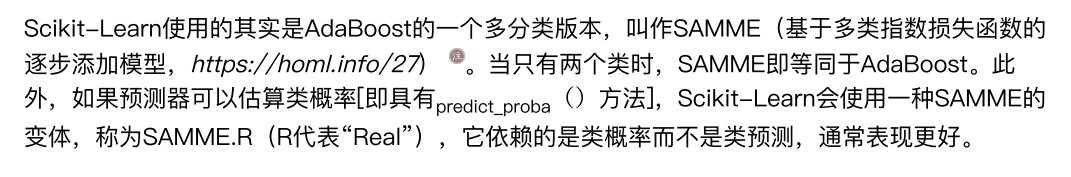

In [21]:
from sklearn.ensemble import AdaBoostClassifier
'''理论上，Adaboost中的预测器并不强制要求同一类型
（虽然绝大多数情况下使用同类模型），方便算法控制复杂度和学习率'''
# 模型构建
#  AdaBoost 最经典的配置是使用大量的“决策树桩”（Decision Stumps，即深度为 1 的决策树）作为基预测器
ada_clf = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1),n_estimators=30,
                            learning_rate=0.5,random_state=42)
ada_clf.fit(X_train,y_train)

,estimator,DecisionTreeC...r(max_depth=1)
,n_estimators,30
,learning_rate,0.5
,algorithm,'deprecated'
,random_state,42
,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


#### 4.2 梯度提升
与AdaBoost一样都是逐步在集成中添加预测器并对前序做出修正，
而不同于AdaBoost在每个迭代中修改权重，这里新的预测器是对前一个预测的残差进行拟合
> 最终将所有树的预测相加。意义就是把这些“修正量”累积起来，使得最终的预测值无限接近真实值 $y$。

In [ ]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

# 生成包含噪声的二次数据集
np.random.seed(42)
X = np.random.rand(100, 1) - 0.5
y = 3 * X[:, 0] ** 2 + 0.05 * np.random.randn(100) # 引入了标准差为 0.05 的白噪声e
# X[:, 0]的形状是(100,)

# 训练第一个预测器
tree_reg1 = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg1.fit(X, y)

# 针对第一个预测器的残差，训练第二个预测器
y2 = y - tree_reg1.predict(X)
tree_reg2 = DecisionTreeRegressor(max_depth=2, random_state=43)
tree_reg2.fit(X, y2)

# 针对第二个预测器的残差，训练第三个预测器
y3 = y2 - tree_reg2.predict(X)
tree_reg3 = DecisionTreeRegressor(max_depth=2, random_state=44)
tree_reg3.fit(X, y3)

# 对新实例进行预测：将所有树的预测相加
X_new = np.array([[-0.4], [0.], [0.5]])
y_pred = sum(tree.predict(X_new) for tree in (tree_reg1, tree_reg2, tree_reg3))

print(y_pred)

[0.49484029 0.04021166 0.75026781]
(100,)


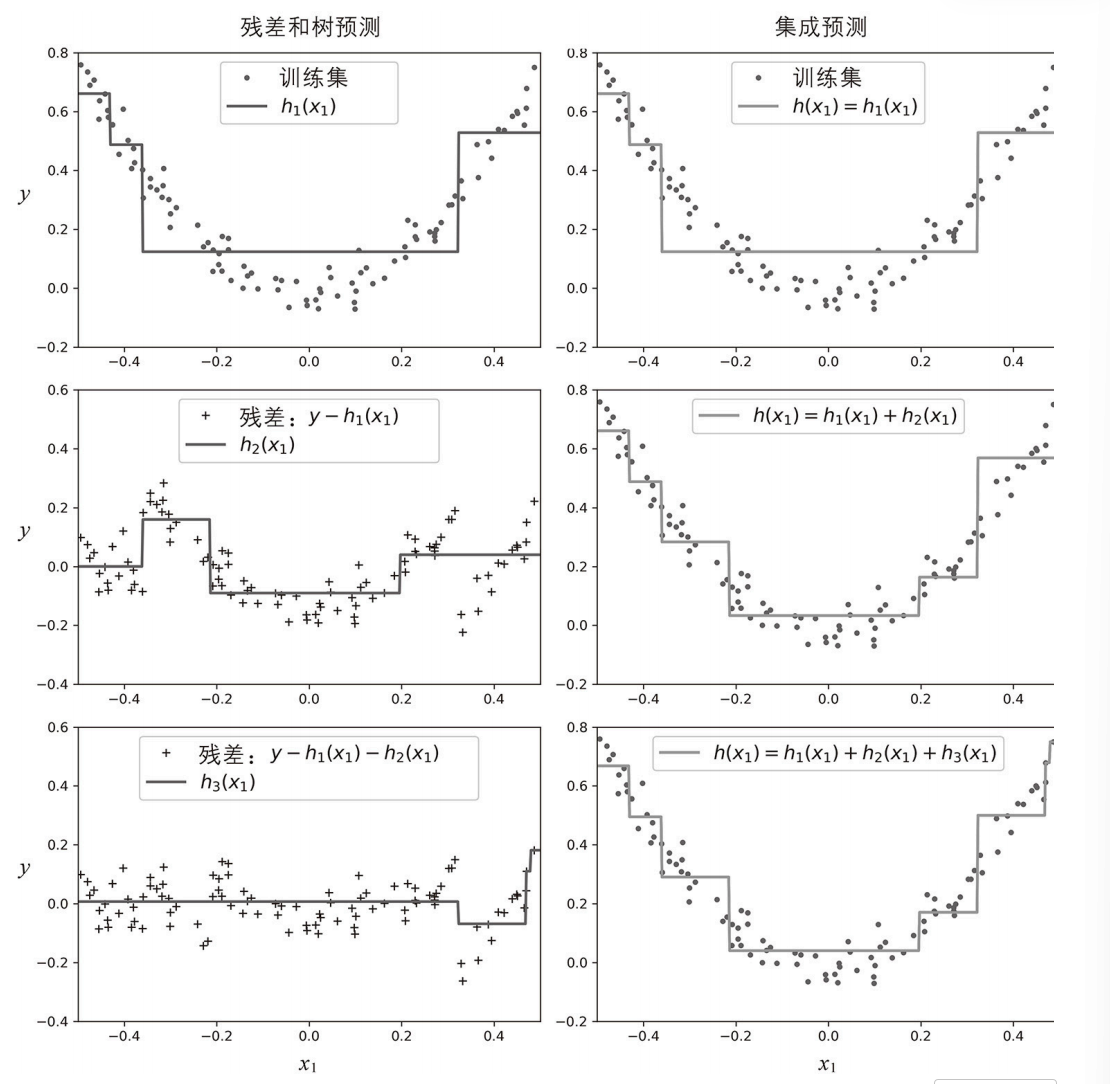
> 当然，同样的，我们也有专门的GradientBoostingRegressor类更轻松地训练GBRT集成

---
#### 下面补充一下提升法中学习率的意义
在提升法（Boosting）中，学习率(Learning-rate)是一个至关重要的超参数。它不仅控制着模型学习的速度，还直接影响着最终模型的泛化能力和稳定性。

### 1. 学习率的核心意义：控制“贡献度”
学习率的主要作用是**缩放每棵树对最终集成模型的贡献**。
*   在预测阶段，最终结果不再是简单地将所有树相加，而是将每棵树的预测结果乘以学习率后再累加。
*   其公式可以表达为：$最终预测 = 树_1 + 学习率 \times 树_2 + 学习率 \times 树_3 + \dots$
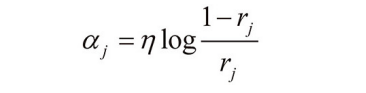  (其中 $r_j$ 可理解为第j个预测器的错误率)

### 2. 学习率在影响什么？

#### 模型的复杂度（树的数量）
*   **权衡关系**：学习率与所需的树的数量（n_estimators）之间存在直接的权衡。
*   **低学习率的代价**：如果将学习率设置得较低，集成模型就需要更多的树来充分拟合训练集。
    *   例如，在某具体情景下，当学习率为 0.05 时，需要多达 92 棵树才能达到良好的拟合效果；而学习率为 1.0 时，仅仅 3 棵树就开始出现剧烈的波动。

> 这实际上是一种正则化技术，提高了模型的泛化能力

#### 拟合的精细程度
*   **高学习率（如 1.0）**：每棵树都试图大幅度修正之前的残差。这会导致决策边界（也就是图中的锯齿状）非常“硬”且不稳定，容易受到噪声点的影响。
*   **低学习率（如 0.05）**：每棵树只做微小的修正。这种“小步快跑”的方式让决策边界更加平滑，能够更精准地捕捉数据的潜在分布趋势。

---

#### 于是这又引出了一个新的问题:如何找到树的最佳数量

### 下面我们介绍交叉验证和早停机制

在提升法（Boosting）中，树的数量（`n_estimators`）是一个关键的权衡点：**树太少会导致欠拟合，树太多则会导致过拟合**。这两种方法通过不同的逻辑来定位那个“刚刚好”的转折点。

#### 1. 交叉验证 (Cross-Validation, CV)
交叉验证（如 `GridSearchCV` 或 `RandomizedSearchCV`）的逻辑是 **“事后检验”**：
*   **模拟测试环境**：它将数据集分成几份，循环地用其中几份训练，剩下的一份作为“伪测试集”（验证集）来评估。
*   **选择最优**：它会尝试你指定的每一个数量（比如 100, 200, 300...）。比较不同树数量在验证集上的平均得分，直接找出泛化误差最小的那个数值。这能有效防止你只在训练集上表现好，而在新数据上崩盘。

#### 2. 早停法 (Early Stopping)
早停法的逻辑是 **“及时止损”**，它在模型训练过程中实时监控表现：
*   **监控进展**：随着树的数量增加，训练误差通常会一直下降，但验证误差在达到某一点后会开始回升。
> 验证误差先降后升的原因:
> 验证误差的变化反映了模型泛化能力的变化，其回升主要由以下因素导致：
> - 从规律到噪声：
>   - 前期：前面的树通常捕捉的是数据中的主要趋势（如 $y = 3x^2$ 的抛物线形状）。此时训练误差和验证误差会同步下降。
>   - 后期：当主要规律被学完后，后续的树开始尝试拟合训练数据中的随机噪声（如测量误差或随机波动）。
*   **耐心机制 (`n_iter_no_change`)**：比如将其设置为 10，意味着如果新增加的 10 棵树都没有让模型表现有实质性提升，算法就认为已经达到了性能极限。
*   **自动收手**：它不需要像交叉验证那样跑完所有的树，一旦发现后续迭代“没帮助”，就会自动停止。这不仅找到了最佳数量，还节省了大量的计算时间。

两者共同的目标都是为了找到那个**验证误差最低的点**，从而确保模型既学习到了数据的规律，又没有去死记硬背数据中的噪声。

In [27]:
from sklearn.ensemble import GradientBoostingRegressor
gbrt_best = GradientBoostingRegressor(
    max_depth=2,learning_rate=0.05,n_estimators=500, # 实际估计器由于受到早停的影响，数量要比500少得多
    n_iter_no_change=10,random_state=42
)
gbrt_best.fit(X,y)
gbrt_best.n_estimators_

92

#### 4.3 基于直方图的梯度提升

#### 1. 核心原理：特征“分箱”（Binning）
传统的决策树在寻找最佳分裂点时，需要遍历特征的所有可能取值，这在数据量极大时非常耗时。
HGB 采用了一种更聪明的做法：**它将连续的输入特征离散化，放进数量有限的“箱子”里，并用整数来代替它们**。
*   在 Scikit-Learn 中，这个箱子的数量由 `max_bins` 控制，默认最大是 255。
*   这就好比把原本精确到小数点的考试分数，粗略地归入“优、良、中、及格、不及格”这几个档次。

### 分箱法具体逻辑:
> 想象我们有一堆凌乱的硬币（原始连续数据），你想根据它们的直径大小来分类。

#### 第一步：预处理——制定“收纳盒”
在正式训练模型之前，算法先看一遍数据，决定如何划分“箱子”的边界。
*   **确定分界点**：算法会根据数据的分布（通常是分位数），把特征的取值范围切成 $b$ 份（默认最多 255 份）。
*   **打标签（离散化）**：原本精确到 13.45mm、13.48mm 的硬币，现在统一标记为“1号箱”；15.12mm 的标记为“2号箱”。
*   **结果**：原始的浮点数矩阵变成了**整数矩阵**。整数不仅占内存小，计算起来也飞快。

#### 第二步：训练时——构建“直方图”
这是 HGB 算法最聪明的地方。当它要训练一棵树并寻找分裂点时，它不再去翻看每一个硬币，而是去统计箱子里的**梯度（误差）信息**：
*   **遍历一次**：它把所有样本走一遍，计算出每个箱子里样本的梯度总和（Sum of Gradients）和样本数量。
*   **生成直方图**：比如 1 号箱的总误差是 10，有 5 个样本；2 号箱总误差是 20，有 8 个样本。

#### 第三步：分裂时——在箱子间“切一刀”
现在算法要决定在哪分裂。
*   **有限的尝试**：如果是传统方法，100 万个硬币可能有 99 万个切点。但现在，它只需要在**箱子与箱子之间**尝试切一刀。
*   **极速计算**：因为总共只有 $b$ 个箱子，它只需要尝试 $b-1$ 次切分（比如 254 次）就能找到让误差下降最快的那个箱子边界。
*   **复杂度骤降**：寻找分裂点的时间不再取决于样本量 $m$，而是取决于箱子数量 $b$。

#### 为什么这样做更有意义？
*   **忽略“杂音”**：13.45mm 和 13.48mm 的微小差异往往是测量误差（噪声）。分箱把它们归为一类，实际上是强迫模型**抓大放小**，起到了一种天然的**正则化**作用，防止模型钻牛角尖（过拟合）。
*   **单边增益**：最神奇的是，由于直方图的数学特性，一旦算出了左边子节点的统计量，右边节点的统计量可以直接用“父节点 - 左边”算出来，速度直接翻倍。

**简单总结**：分箱法就是把 **“无限可能的精确位置”** 压缩成了 **“有限的固定坑位”**，从而把查表排序的重活变成了简单的加减法统计。

---
#### 2. 数学视角的降维打击：时间复杂度优化（这里只关注训练迭代过程中的复杂度）
这是 HGB 能比常规 GBRT 快几百倍的根本原因。
*   **传统 GBRT**：在训练每一棵树时，都需要根据某个特征对样本进行排序以寻找最佳分裂点。排序操作的复杂度通常是对数级别的。因此，它的计算复杂度为 $O(n \times m \times \log(m))$，其中 $n$ 是特征数，$m$ 是实例数。
*   **HGB**：因为特征已经被预先转换成了最多 255 个整数箱子，算法**不再需要在训练每棵树时对特征进行排序**。评估可能阈值的数量大大减少，这使得计算复杂度断崖式下降到了 $O(b \times m)$，其中 $b$ 是箱子的数量。
*   此外，使用整数运算和数据结构不仅速度更快，而且极大地节省了内存。

理解这两个复杂度的差异，关键在于理解决策树在寻找“最佳分裂点”时是如何处理数据的。

#### 一. 传统 GBRT 的复杂度：$O(n \times m \times \log(m))$
这个复杂度的核心消耗在**排序**上。
*   **$m \times \log(m)$ (排序成本)**：传统的决策树（如 CART）在处理连续特征时，需要对每个特征的所有样本值进行**排序**。这是为了能按顺序遍历所有可能的切分点（阈值）。对于 $m$ 个实例，排序的时间复杂度通常是 $O(m \log m)$。
*   **$n$ (特征维度)**：由于模型有 $n$ 个特征，它必须对每一个特征都执行上述排序操作。
*   **合并计算**：因此，在每一棵树的训练过程中，寻找最佳分裂点的复杂度就是特征数乘以排序成本，即 $O(n \times m \log m)$。当数据量 $m$ 达到百万级别时，$m \log m$ 会变得非常巨大。

#### 二. HGB 的复杂度：$O(b \times m)$
HGB 的核心优化在于**消除排序**并限制了**搜索空间的上限**。
*   **预处理分箱**：HGB 在开始训练前，先将所有连续特征离散化到 $b$ 个桶（箱子）中（通常 $b=255$）。
*   **$m$ (统计成本)**：在训练时，算法只需要遍历一次数据集（$m$ 个实例），将它们分配到对应的直方图箱子里，并统计每个箱子内的梯度信息。这个过程是线性的。
*   **$b$ (评估成本)**：在寻找分裂点时，算法不再需要考虑 $m$ 个可能的阈值，而只需要考虑 $b$ 个箱子的边界。因为 $b$ 是一个固定的常数（且 $b \ll m$），评估成本大大降低。
*   **合并计算**：训练时的主要工作量变成了构建直方图，复杂度为 $O(b \times m)$。

---
#### 3. 一把双刃剑：精度损失与正则化
实际上，分箱会导致一定的精度损失。

但这在机器学习中往往因祸得福：这种精度损失**充当了正则化的角色**。它让树无法过于精细地去贴合那些微小的噪声点，这在很多时候有助于减少过拟合（当然，如果原本数据就很简单，也可能导致欠拟合）。

#### 4. Scikit-Learn API 的一些“特权”与限制
因为底层的计算逻辑变了，`HistGradientBoostingRegressor` 和分类器在参数调用上与常规的提升树有所不同：
*   **重命名**： `n_estimators`（树的数量）在这里被重命名为了 `max_iter`。
*   **自动早停**：如果训练实例超过 10000 个，模型为了节省时间，会自动激活早停机制（通过 `early_stopping` 参数控制）。
*   **参数精简**：它不支持子采样，且能调整的决策树结构超参数仅限于 `max_leaf_nodes`、`min_samples_leaf` 和 `max_depth`。

#### 5. 预处理的便捷之处：原生支持类别与缺失值
*   **自带“填坑”和“翻译”能力**：HGB 原生支持处理分类特征和缺失值，这意味着你在构建流水线（Pipeline）时，**无须再使用填补器（Imputer）、缩放器（Scaler）或独热编码器（One-Hot Encoder）**。
*   **唯一要求**：你只需要用 `OrdinalEncoder` 将分类特征转换为从 0 到小于 `max_bins` 的整数即可，并在模型初始化时通过 `categorical_features` 参数告诉模型哪些列是分类特征。
这段内容涉及到基于直方图的梯度提升（HGB）在工程实现上非常关键的几个特性，以及梯度提升算法底层的数学原理。我们分模块来详细拆解。

> 怎么理解这里的原生支持类别与缺失值

传统的机器学习模型（如标准的 GBRT 或随机森林）在接收数据前，通常要求数据是一个完美的、纯数字的矩阵。HGB 打破了这个限制：

*   **无需独热编码（One-Hot Encoding）：** 传统决策树在处理诸如“城市”（北京、上海、广州）这样的分类特征时，如果直接映射为 0, 1, 2，模型会误以为它们存在大小关系（2 > 1 > 0）。因此传统做法是展开成多列的独热编码（如 is_北京=1, is_上海=0）。但在树模型中，独热编码会导致特征空间变得极其稀疏，树往往需要长得很深才能学到规律。
    *   **HGB的解法：** HGB 允许你用 `OrdinalEncoder` 将类别简单地映射为 0 到 $max\_bins - 1$ 的整数。只要你通过 `categorical_features` 参数声明了这些列是分类特征，HGB 底层在寻找分割点时，就不会按大小顺序去切一刀（比如 $\le 1$ 分布在左，$>1$ 分布在右），而是会将类别按其在目标变量上的统计表现（如平均梯度）重新排序，或者评估类别的不同子集，从而寻找最佳的“类别集合”进行分裂。
*   **无需填补器（Imputer）处理缺失值：** 传统模型遇到 `NaN`（缺失值）会直接报错。
    *   **HGB的解法：** HGB 在构建直方图时，会为缺失值单独保留一个位置。在计算节点分裂时，它会分别尝试将所有包含缺失值的样本全部分配给左子节点，然后再尝试全部分配给右子节点。哪种分配方式能带来更大的**损失下降（Gain）**，就把缺失值默认往那边分。

---

In [ ]:
# 导入库
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
'''导入列转换器，允许对数据集中不同的列应用不同的预处理操作
（例如，只对某一列进行编码，而保留其他列）'''
from sklearn.ensemble import HistGradientBoostingRegressor
'''导入基于直方图的梯度提升回归模型。
这是专门针对大数据集优化的 GBRT 实现'''
from sklearn.preprocessing import OrdinalEncoder
# 导入顺序编码器，用于将分类标签（字符串）转换为整数。

# 构建处理流程
hgb_reg = make_pipeline(
    # 数据预处理
    make_column_transformer((OrdinalEncoder(), ["ocean_proximity"]),
                            remainder="passthrough"), # 转化后的类别列会被置于最左边
    # 列转换器的配置项，表示除了 "ocean_proximity" 之外的其他特征列都原封不动地通过
    HistGradientBoostingRegressor(categorical_features=[0], random_state=42)
    # categorical_features=[0]：非常关键的设置。它告诉模型，经过前一步处理后，
    # 索引为 0 的列（即转换后的类别列）应当被视作分类特征处理，而不是普通的数值特征。
)
# hgb_reg.fit(housing, housing_labels)

### 5. 堆叠法

#### 下面展示的是多层堆叠的预测过程（不是训练过程）
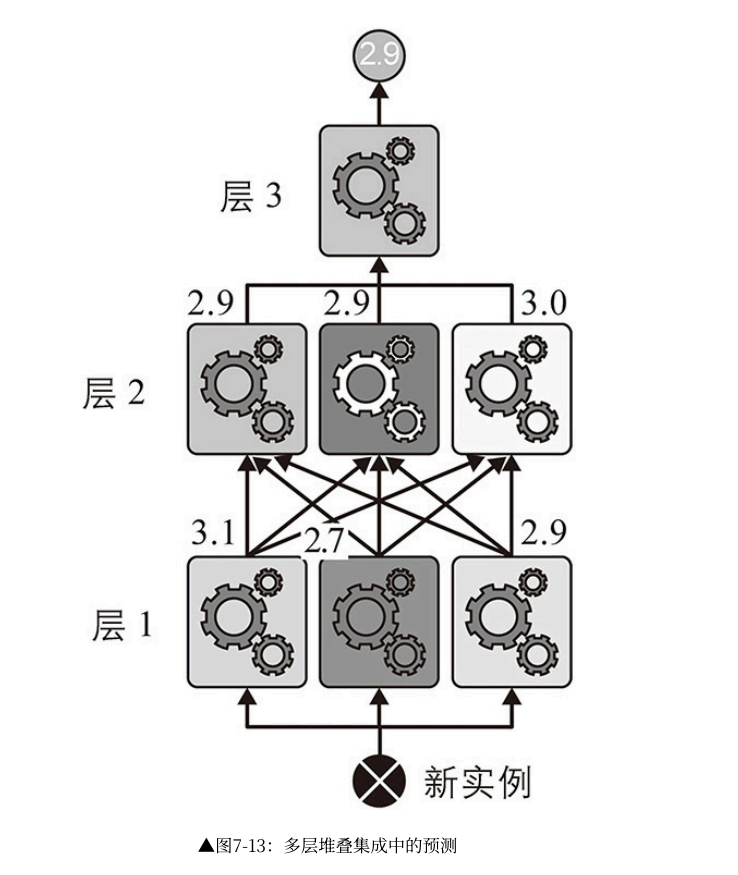

In [ ]:
# 模型构建
from sklearn.ensemble import StackingClassifier
stacking_clf = StackingClassifier(
    estimators=[
        ('lr',LogisticRegression(random_state=42)),
        ('rf',RandomForestClassifier(random_state=42)),
        ('svc',SVC(random_state=42))
    ],
    final_estimator=RandomForestClassifier(random_state=43),
    cv=5 # cv 代表 交叉验证（Cross-Validation） 的折数
)
stacking_clf.fit(X_train,y_train)

,estimators,"[('lr', ...), ('rf', ...), ...]"
,final_estimator,RandomForestC...ndom_state=43)
,cv,5
,stack_method,'auto'
,n_jobs,None
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


### 补充两个疑惑
#### 1. 初级模型的预测值是怎么添加的？
这是一个数据维度的变换过程。初级模型的预测值并不是简单地“挂”在原始特征后面，而是构成了一个**全新的特征矩阵**。

*   **数据拼接逻辑**：
    1.  假设你有 $M$ 个原始特征，训练了 3 个初级模型（如你代码中的 `lr`, `rf`, `svc`）。
    2.  通过交叉验证，每个模型会为每个样本生成一个预测结果（分类任务中通常是概率值）。
    3.  最终，这 3 个预测结果会水平拼接，形成一个 **$N \times 3$** 的新矩阵。
*   **注意**：在 Scikit-Learn 的默认设置中，元学习器（`final_estimator`）通常**只接收这些预测值**作为输入特征，而不包含原始的 $M$ 个特征。当然，你可以通过参数设置将它们混合，但标准的 Stacking 倾向于让元学习器专注于“整合各家之言”。

#### 2. 元学习器与原始的输入特征数据
在 Scikit-Learn 的 `StackingClassifier` 或 `StackingRegressor` 默认实现中，**元学习器（Final Estimator）通常不会直接接触到原始的输入特征数据**。

### 一. 默认流程：只“听取”初级模型的意见
在默认情况下，Stacking 的数据流向是线性的：
*   **输入**：原始特征 $X$ 进入初级模型。
*   **中间产物**：初级模型输出预测值（分类任务通常是概率，回归任务是数值）。
*   **元学习器的输入**：元学习器只拿这些**预测值**作为它自己的训练特征（Meta-features）。

> **逻辑推导**：如果元学习器只看预测值，它的任务就非常纯粹——学习如何给不同专家的意见分配权重。比如，它可能会学到：“当随机森林和 SVC 的结果冲突时，通常随机森林更准”。

#### 二. 特殊配置：包含原始数据（Passthrough）
虽然默认不使用，但 Scikit-Learn 提供了一个参数 `passthrough`。
*   如果你设置 `passthrough=True`，元学习器接收到的特征矩阵将是：**[初级模型的预测值 + 原始特征数据]**。
*   **作用**：这允许元学习器结合原始特征来做决策。例如，它可能会发现：“在特征 A 的数值很大时，模型 1 的预测不可信，需要多参考模型 2”。

#### 三. 元学习器如何处理“混合”数据？
当元学习器面对这种混合数据（预测值+原始特征）时，它在算法层面并不区分它们的来源，而是**统一视为特征列**：

*   **特征拼接**：假设原始有 10 个特征，你有 3 个初级模型，元学习器就会看到一个维度为 13 的特征向量。
*   **统一学习**：元学习器（比如你代码中的随机森林）会像处理任何普通数据集一样，计算这 13 个特征的特征重要性或分裂点。
*   **目标一致**：无论输入是多么复杂，元学习器始终是在拟合**原始标签 $y$**。它通过损失函数对比自己的输出与真实标签，从而不断调整这 13 个特征的利用方式。
当你在 Stacking 中开启 `passthrough=True` 试图混用原始特征与初级模型的输出概率时，本质上是将不同维度的信息放在同一个特征矩阵中进行处理。

---
> 元学习器并不会被“混合”的数据难住，因为在算法眼里，无论是原始特征还是预测概率，都只是矩阵中的一列数值。针对你提到的不同数据类型，处理逻辑如下：

#### 1. 数据的“同质化”处理
要让元学习器同时处理“具体的词”和“连续的概率”，必须先通过**预处理流水线**将它们全部转换为数值形式：

*   **具体词汇（类别特征）**：不能直接喂给模型。正如你之前代码中使用的 `OrdinalEncoder`，它会将这些词汇映射为整数（如“靠近海洋”=0，“内陆”=1）。
*   **连续值与概率**：它们本身就是数值，可以直接进入矩阵。
*   **最终形态**：元学习器看到的输入矩阵 $X_{meta}$ 每一行可能长这样：
    `[类别ID, 连续数值1, 连续数值2, 模型A概率, 模型B概率, 模型C概率]`。

#### 2. 不同元学习器的处理差异
元学习器如何“混用”这些数据，取决于你选择了什么模型：

| 元学习器类型 | 处理逻辑 | 混用效果 |
| :--- | :--- | :--- |
| **随机森林 (RF)** | 通过寻找最优分裂点来处理特征。它会对比“类别ID是否为0”或“模型A概率是否 > 0.8”哪个能让损失下降更多。 | **非常擅长**。树模型天生能处理不同尺度和类型的特征，不需要做缩放。 |
| **逻辑回归 (LR)** | 给每个特征分配一个权重系数 $w$。公式为：$y = \sigma(w_1 \cdot \text{词汇ID} + w_2 \cdot \text{概率} + ...)$。 | **较弱**。它会把类别ID当成连续数值计算，效果通常不好。且概率值范围是 [0, 1]，如果原始特征范围很大（如 0-10000），需要先做归一化。 |

**总结建议：**
如果你想混用这些数据，元学习器首选**随机森林**或 **XGBoost/LightGBM** 等树模型，因为它们对特征的量纲（单位）不敏感，能完美融合“类别编号”、“原始数值”和“预测概率”。

---
#### 四. 为什么默认不使用原始数据？
*   **计算效率**：元学习器通常使用较简单的模型（如 Logistic 回归），如果原始数据维度很高，会增加元学习器的训练压力。
*   **防止过拟合**：初级模型已经从原始数据中提取了最关键的信息。如果元学习器再次接触原始数据，有时会过度依赖某些原始强特征，而忽略了整合多个模型意见的初衷，导致性能反而不如简单整合。